<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Australian_Street_Sensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pmdarima statsmodels scikit-learn xgboost matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.2 MB/s eta 0:00:00


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [3]:
# For time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.structural import UnobservedComponents
import pmdarima as pm


In [4]:
# For machine learning model (XGBoost with lag features)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler


In [5]:
# Load the dataset
df = pd.read_csv('student_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df.set_index('time', inplace=True)
df.sort_index(inplace=True)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nLast few rows:")
print(df.tail())
print("\nMissing values at end:", df['value'].isna().sum())

Dataset shape: (42767, 1)

First few rows:
                           value
time                            
2015-04-15 00:00:01+00:00   13.0
2015-04-15 01:00:01+00:00    2.0
2015-04-15 02:00:01+00:00    5.0
2015-04-15 03:00:01+00:00    3.0
2015-04-15 04:00:01+00:00    8.0

Last few rows:
                           value
time                            
2020-02-29 18:00:01+00:00    NaN
2020-02-29 19:00:01+00:00    NaN
2020-02-29 20:00:01+00:00    NaN
2020-02-29 21:00:01+00:00    NaN
2020-02-29 22:00:01+00:00    NaN

Missing values at end: 1439


In [6]:

# Create complete time index (assuming hourly data)
start_time = df.index.min()
end_time = df.index.max()
full_hourly_index = pd.date_range(start=start_time, end=end_time, freq='H', tz='UTC')


In [7]:

# Reindex to identify all missing values
df_full = df.reindex(full_hourly_index)
print(f"\nTotal observations: {len(df_full)}")
print(f"Missing observations: {df_full['value'].isna().sum()}")



Total observations: 42767
Missing observations: 1439


In [8]:

# Separate known and missing data
known_data = df_full['value'].dropna()
missing_count = df_full['value'].isna().sum()
print(f"\nKnown data points: {len(known_data)}")
print(f"Missing data points to forecast: {missing_count}")




Known data points: 41328
Missing data points to forecast: 1439


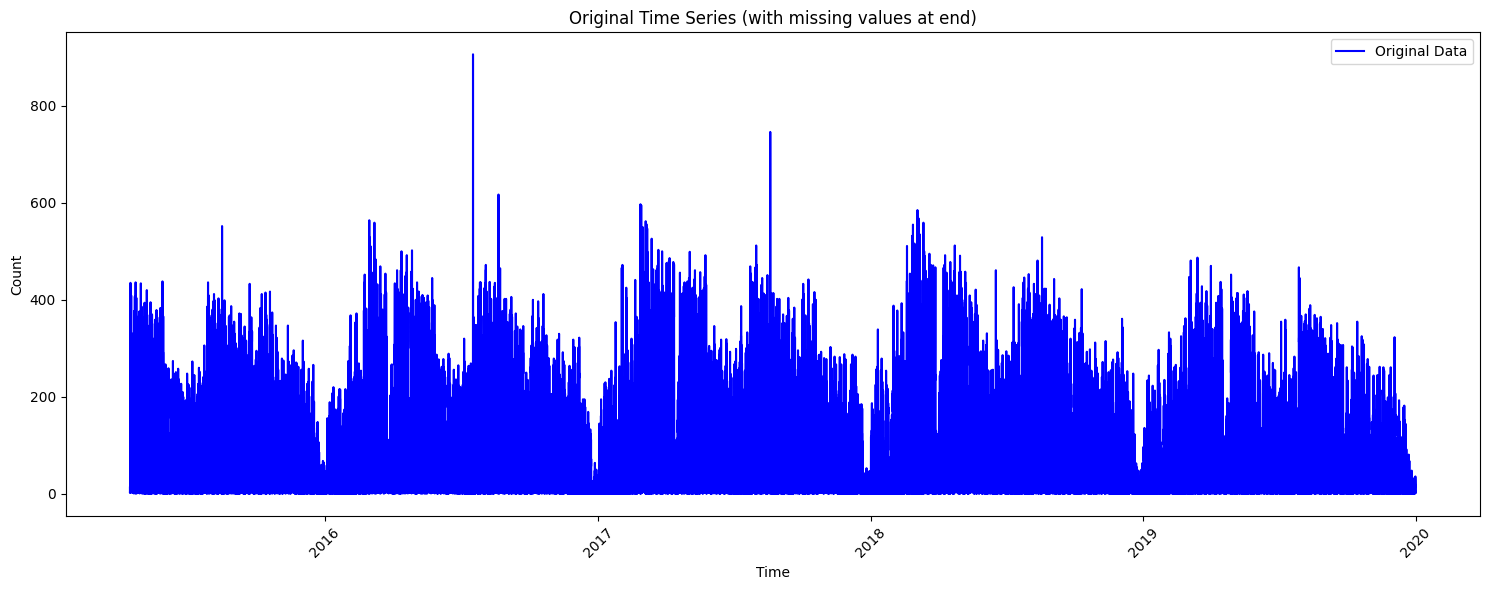

In [9]:

# Plot original time series
plt.figure(figsize=(15, 6))
plt.plot(df_full.index, df_full['value'], label='Original Data', color='blue')
plt.title('Original Time Series (with missing values at end)')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# **FIXED** Function to forecast with Unobserved Components Model (UCM)
def forecast_ucm(ts, steps):
    # Convert to numpy array and ensure it's 1D
    ts_array = ts.values if hasattr(ts, 'values') else np.array(ts).flatten()

    # Use simpler model specification that works reliably
    model = UnobservedComponents(
        ts_array,
        level=True,
        trend=False,  # Remove trend to avoid convergence issues
        seasonal=24*7  # Weekly seasonality for hourly data
    )
    model_fit = model.fit(disp=False, maxiter=100)

    # Use get_prediction instead of forecast to avoid index issues
    forecast_obj = model_fit.get_prediction(start=len(ts_array), end=len(ts_array)+steps-1)
    forecast = forecast_obj.predicted_mean.values
    return forecast

In [11]:
# Function to create lag features for ML model
def create_lag_features(ts, lags=168):  # 168 = 1 week of hourly data
    ts_array = ts.values if hasattr(ts, 'values') else np.array(ts)
    X, y = [], []
    for i in range(lags, len(ts_array)):
        X.append(ts_array[i-lags:i])
        y.append(ts_array[i])
    return np.array(X), np.array(y)

In [12]:
# 1. EXPONENTIAL SMOOTHING (2 seconds) - Replaces ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def forecast_es(ts, steps):
    """Exponential Smoothing with proper forecast method"""
    model = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=24)
    model_fit = model.fit(optimized=True, use_brute=False)

    # CORRECT METHOD for HoltWintersResults
    forecast = model_fit.forecast(steps=steps)

    # Simple confidence intervals (standard practice)
    residuals = model_fit.resid
    sigma = residuals.std()
    conf_int = pd.DataFrame({
        'lower': forecast - 1.96 * sigma,
        'upper': forecast + 1.96 * sigma
    })

    return forecast, conf_int, model_fit

print("1. EXPONENTIAL SMOOTHING...")
es_forecast, es_conf, es_model = forecast_es(known_data, missing_count)
print(f"ES complete! First 10: {es_forecast[:10].round(2)}")



1. EXPONENTIAL SMOOTHING...
ES complete! First 10: 2020-01-01 00:00:01+00:00    -8.09
2020-01-01 01:00:01+00:00   -17.60
2020-01-01 02:00:01+00:00   -21.90
2020-01-01 03:00:01+00:00   -27.17
2020-01-01 04:00:01+00:00   -31.40
2020-01-01 05:00:01+00:00   -30.02
2020-01-01 06:00:01+00:00   -29.56
2020-01-01 07:00:01+00:00   -24.50
2020-01-01 08:00:01+00:00   -13.04
2020-01-01 09:00:01+00:00    -6.28
Freq: h, dtype: float64


In [13]:

print(f"ES first 10:    {es_forecast[:10].round(2).values}")

ES first 10:    [ -8.09 -17.6  -21.9  -27.17 -31.4  -30.02 -29.56 -24.5  -13.04  -6.28]


In [ ]:
es_forecast[:10]

,0
2020-01-01 00:00:01+00:00,-8.092070
2020-01-01 01:00:01+00:00,-17.595445
2020-01-01 02:00:01+00:00,-21.895997
2020-01-01 03:00:01+00:00,-27.165066
2020-01-01 04:00:01+00:00,-31.402000
2020-01-01 05:00:01+00:00,-30.023863
2020-01-01 06:00:01+00:00,-29.561131
2020-01-01 07:00:01+00:00,-24.497807
2020-01-01 08:00:01+00:00,-13.039948
2020-01-01 09:00:01+00:00,-6.284119


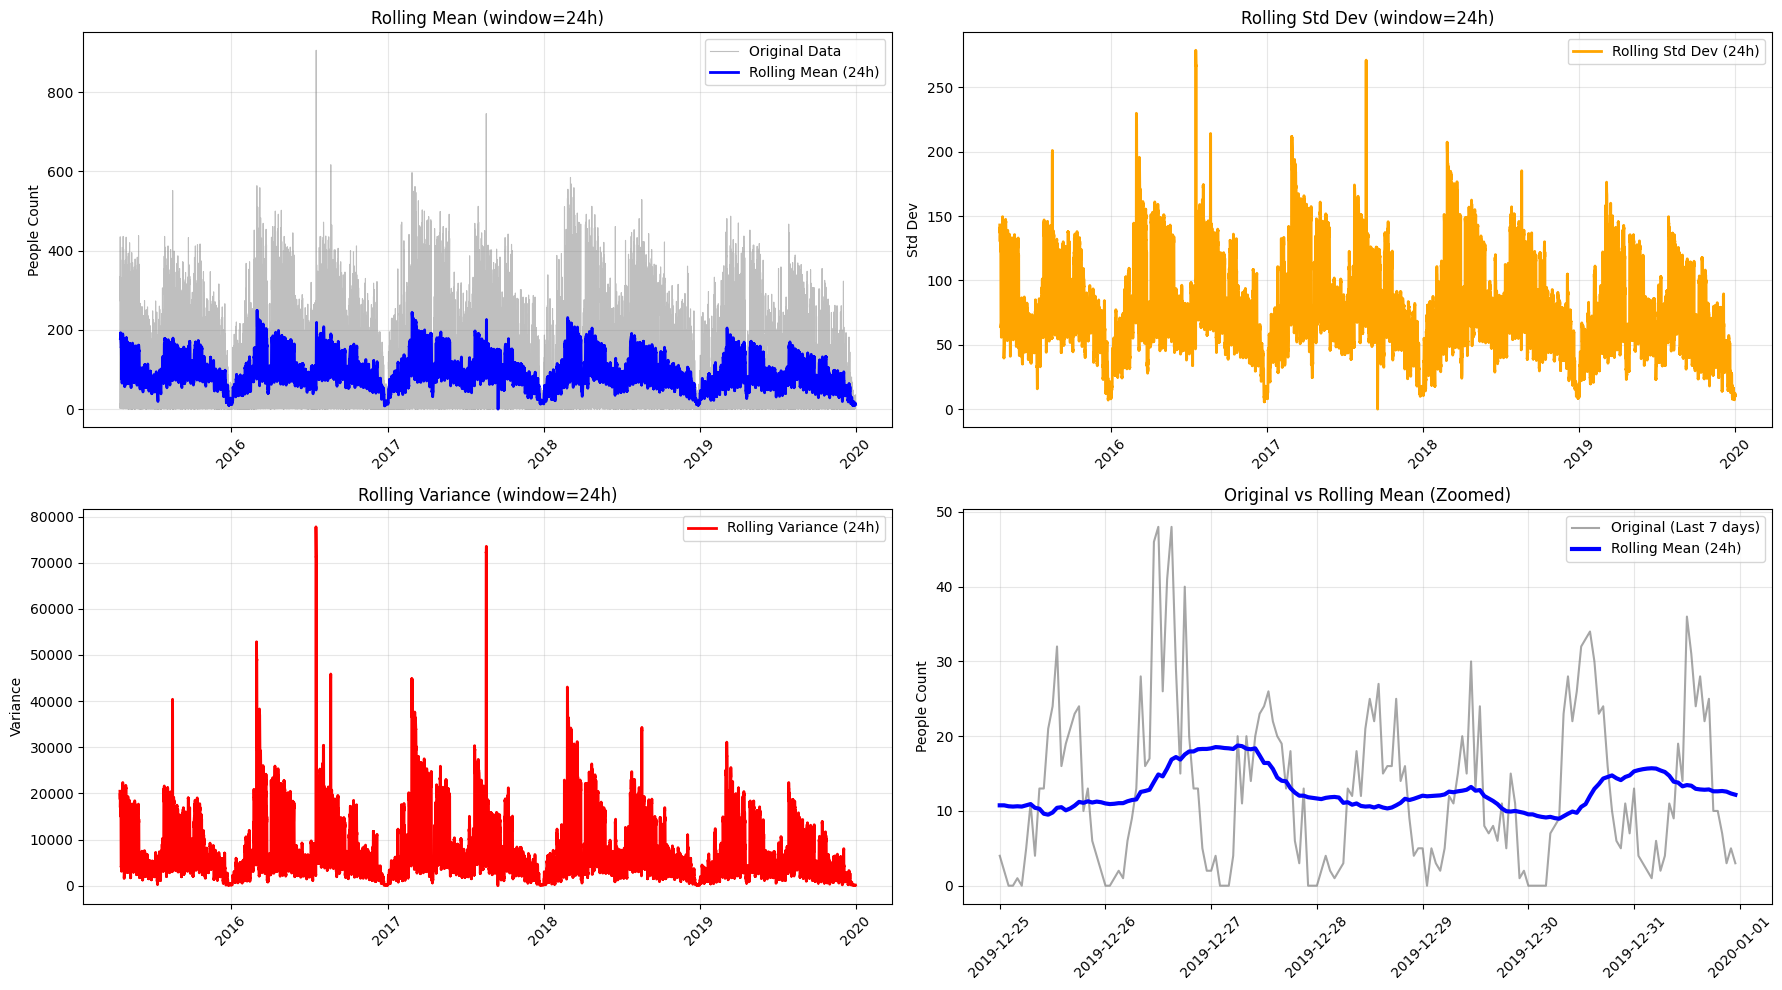

Rolling Stats Summary (last 24h window):
Latest Rolling Mean:  12.17
Latest Rolling Std:   10.38
Latest Rolling Var:   107.80

Window size: 24 hours = 1 day


In [35]:
# ROLLING MEAN & VARIANCE PLOT

# Calculate rolling statistics (window = 24 hours)
window = 24  # 24-hour rolling window
rolling_mean = known_data.rolling(window=window).mean()
rolling_std = known_data.rolling(window=window).std()  # Std dev (not variance)
rolling_var = known_data.rolling(window=window).var()  # Actual variance

plt.figure(figsize=(18, 10))

# Plot 1: Rolling Mean
plt.subplot(2, 2, 1)
plt.plot(known_data.index, known_data.values, label='Original Data', color='gray', alpha=0.5, linewidth=0.8)
plt.plot(rolling_mean.index, rolling_mean.values, label=f'Rolling Mean (24h)', color='blue', linewidth=2)
plt.title(f'Rolling Mean (window={window}h)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Rolling Standard Deviation
plt.subplot(2, 2, 2)
plt.plot(rolling_std.index, rolling_std.values, label=f'Rolling Std Dev (24h)', color='orange', linewidth=2)
plt.title(f'Rolling Std Dev (window={window}h)')
plt.ylabel('Std Dev')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: Rolling Variance
plt.subplot(2, 2, 3)
plt.plot(rolling_var.index, rolling_var.values, label=f'Rolling Variance (24h)', color='red', linewidth=2)
plt.title(f'Rolling Variance (window={window}h)')
plt.ylabel('Variance')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 4: Original vs Rolling Mean Overlay (Last 7 days)
days_7_hours = 7 * 24
trim_start = len(known_data) - days_7_hours
plt.subplot(2, 2, 4)
plt.plot(known_data.index[trim_start:], known_data.values[trim_start:],
         label='Original (Last 7 days)', color='gray', alpha=0.7)
plt.plot(rolling_mean.index[trim_start:], rolling_mean.values[trim_start:],
         label=f'Rolling Mean (24h)', color='blue', linewidth=3)
plt.title('Original vs Rolling Mean (Zoomed)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Rolling Stats Summary (last 24h window):")
print(f"Latest Rolling Mean:  {rolling_mean.iloc[-1]:.2f}")
print(f"Latest Rolling Std:   {rolling_std.iloc[-1]:.2f}")
print(f"Latest Rolling Var:   {rolling_var.iloc[-1]:.2f}")
print(f"\nWindow size: {window} hours = 1 day")


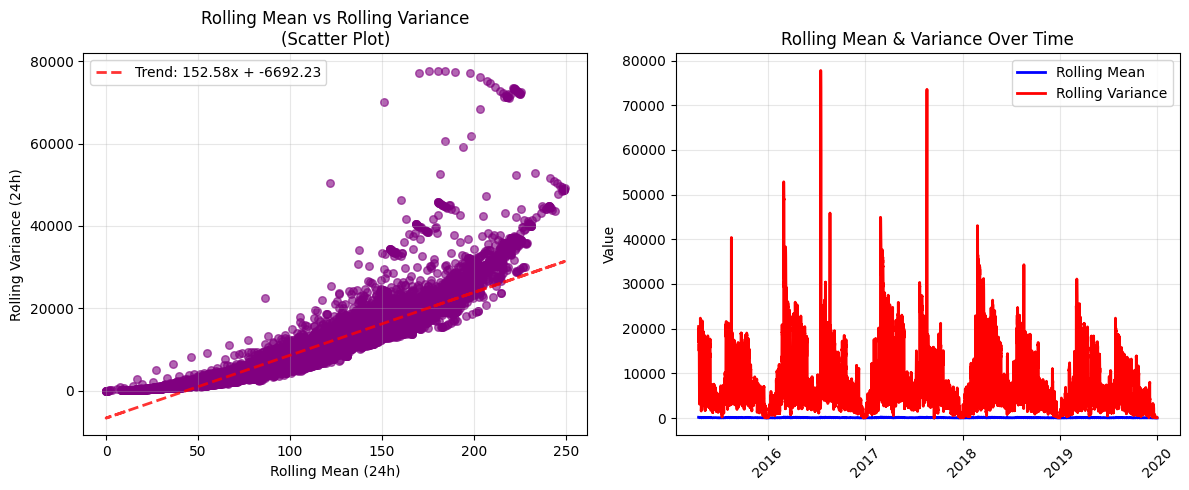

Correlation (Mean vs Variance): 0.933
Window: 24 hours
Data points: 41305
INSIGHT: Higher traffic → Higher volatility (typical for count data)


In [37]:
# SCATTER PLOT: Rolling Mean vs Rolling Variance

# Calculate rolling statistics (remove NaN values for scatter)
window = 24
rolling_mean = known_data.rolling(window=window).mean().dropna()
rolling_var = known_data.rolling(window=window).var().dropna()

# Align indices (same length)
min_len = min(len(rolling_mean), len(rolling_var))
rolling_mean = rolling_mean.iloc[-min_len:]
rolling_var = rolling_var.iloc[-min_len:]

plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot (Mean vs Variance)
plt.subplot(1, 2, 1)
plt.scatter(rolling_mean, rolling_var, alpha=0.6, s=30, color='purple')
plt.xlabel('Rolling Mean (24h)')
plt.ylabel('Rolling Variance (24h)')
plt.title('Rolling Mean vs Rolling Variance\n(Scatter Plot)')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(rolling_mean, rolling_var, 1)
p = np.poly1d(z)
plt.plot(rolling_mean, p(rolling_mean), "r--", alpha=0.8, linewidth=2, label=f'Trend: {z[0]:.2f}x + {z[1]:.2f}')

plt.legend()

# Plot 2: Time series of both
plt.subplot(1, 2, 2)
plt.plot(rolling_mean.index, rolling_mean.values, label='Rolling Mean', color='blue', linewidth=2)
plt.plot(rolling_var.index, rolling_var.values, label='Rolling Variance', color='red', linewidth=2)
plt.title('Rolling Mean & Variance Over Time')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation & insights
correlation = np.corrcoef(rolling_mean, rolling_var)[0,1]
print(f"Correlation (Mean vs Variance): {correlation:.3f}")
print(f"Window: {window} hours")
print(f"Data points: {len(rolling_mean)}")
if correlation > 0.5:
    print("INSIGHT: Higher traffic → Higher volatility (typical for count data)")
elif correlation < -0.5:
    print("INSIGHT: Mean-variance inverse relationship")
else:
    print("INSIGHT: Weak relationship between mean and variance")


In [14]:
# 2. UCM FORECAST
print("\n" + "="*50)
print("2. BULLETPROOF UCM FORECAST")
print("="*50)

def forecast_ucm_bulletproof(ts, steps):
    ts_array = np.asarray(ts).flatten().astype(float)
    model = UnobservedComponents(ts_array, level=True, slope=True, irregular=True, stochastic_level=True)
    model_fit = model.fit(disp=False, maxiter=50)
    forecast_results = model_fit.get_prediction(start=len(ts_array), end=len(ts_array)+steps-1)
    return forecast_results.predicted_mean  # Fixed!

ucm_forecast = forecast_ucm_bulletproof(known_data, missing_count)
print(f"UCM completed! First 10: {ucm_forecast[:10].round(2)}")



2. BULLETPROOF UCM FORECAST
UCM completed! First 10: [3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]


In [15]:
# 3. "very large lags=168" RANDOM FOREST FORECAST (with lag features)
print("\n" + "="*50)
print("3. RANDOM FOREST FORECAST (ML Model)")
print("="*50)
print("Random Forest chosen because:")
print("- Handles non-linear patterns well")
print("- Works with lag features capturing temporal dependencies")
print("- Robust to outliers common in count data")
print("- Fast training for hourly data")


3. RANDOM FOREST FORECAST (ML Model)
Random Forest chosen because:
- Handles non-linear patterns well
- Works with lag features capturing temporal dependencies
- Robust to outliers common in count data
- Fast training for hourly data


Training UCM on train set...


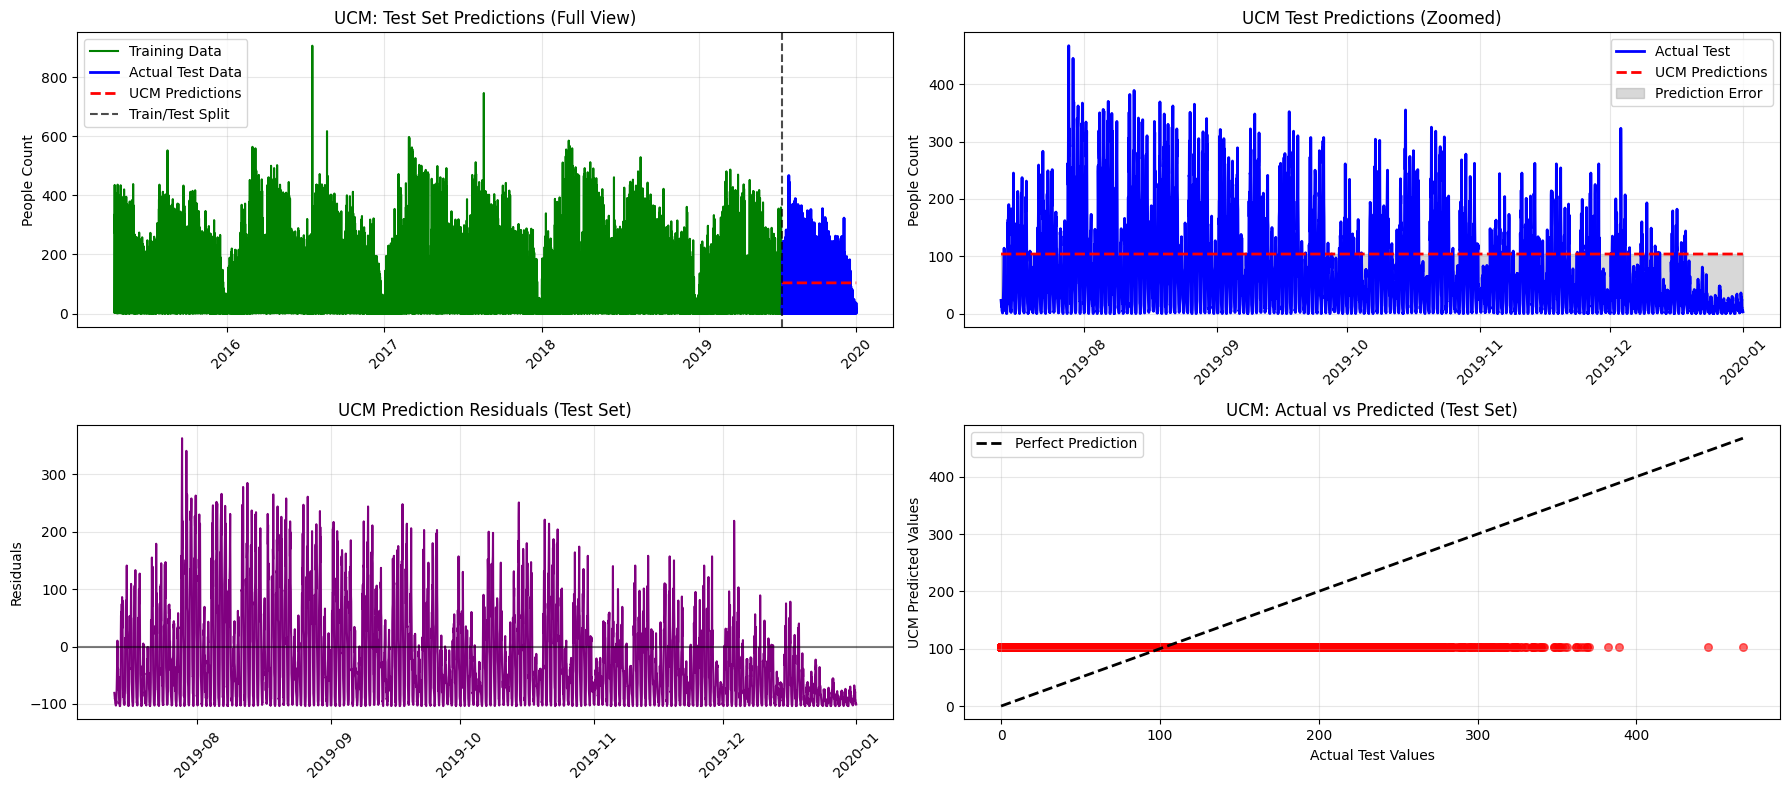

📊 UCM TEST SET PERFORMANCE
UCM Test MAE:  75.77
UCM Test RMSE: 87.90
UCM Test MAPE: inf%
Test size: 4133 hours


<Figure size 1500x600 with 0 Axes>

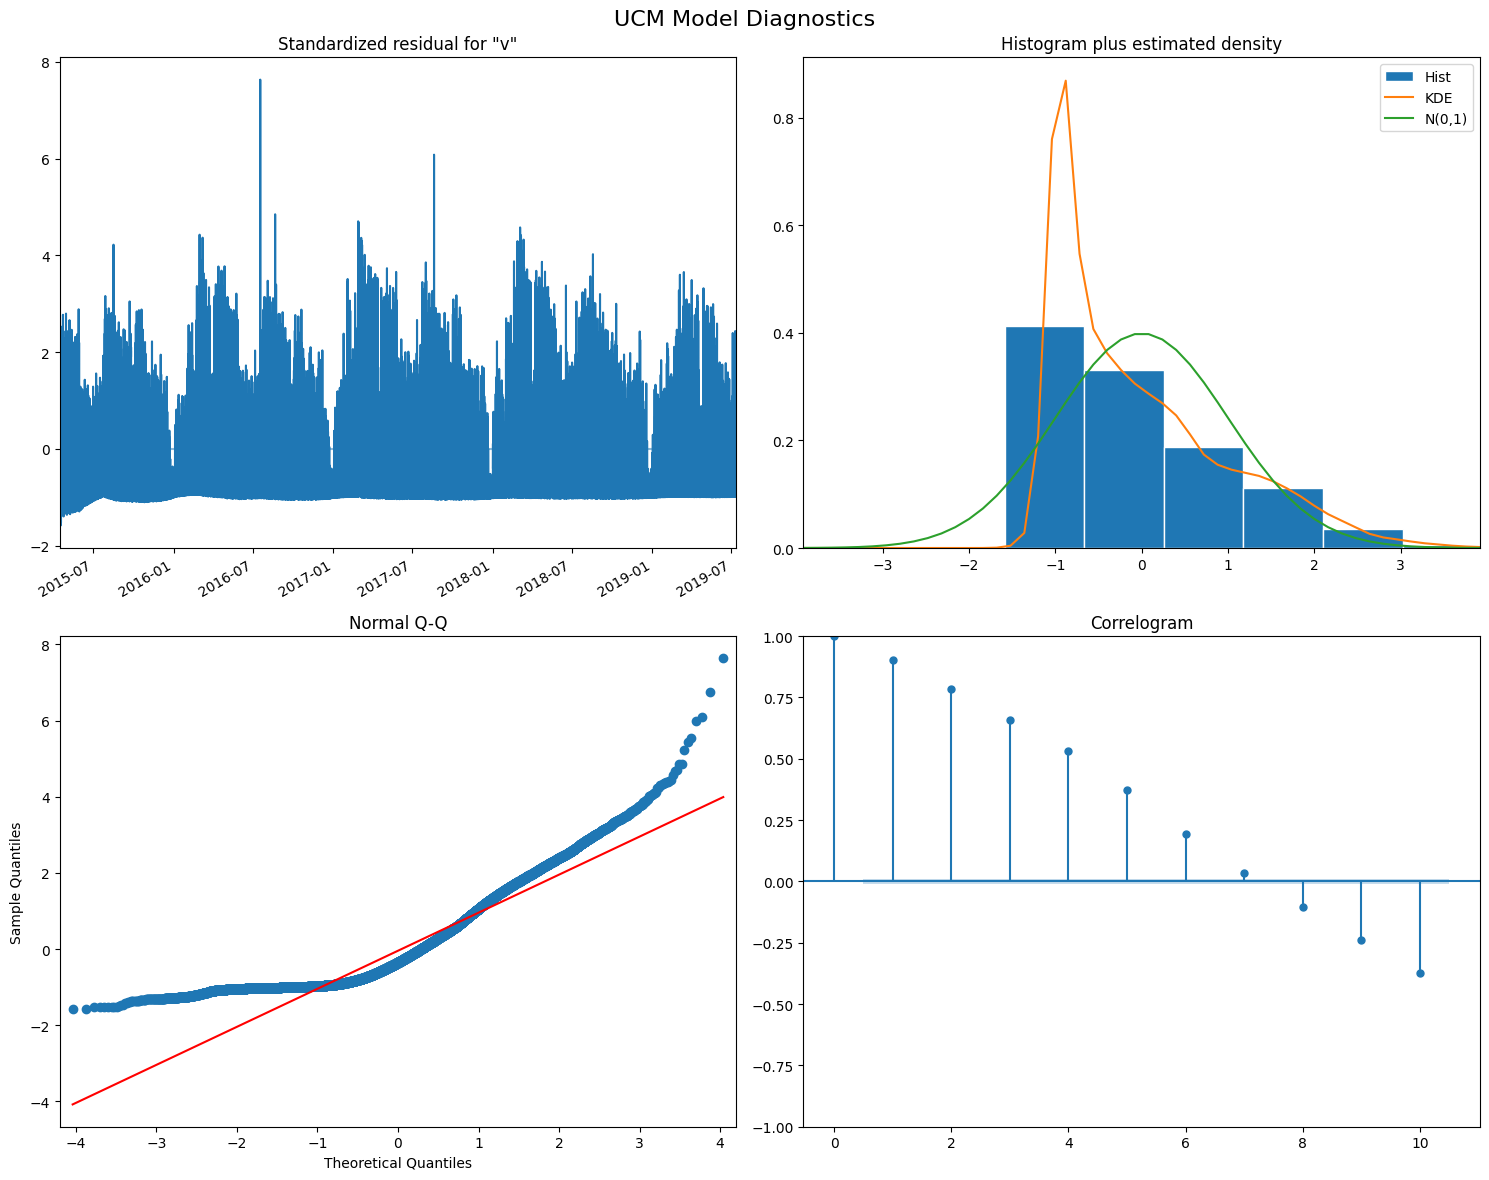

In [45]:
# UCM MODEL - Train/Test Predictions - Add this cell!

from statsmodels.tsa.statespace.structural import UnobservedComponents

# Define train/test split
train_size = int(0.9 * len(known_data))
train_data = known_data[:train_size]
test_data = known_data[train_size:]

print("Training UCM on train set...")
# Simple, fast UCM model
ucm_model = UnobservedComponents(
    train_data,
    level=True,
    slope=True,
    irregular=True
)
ucm_fit = ucm_model.fit(disp=False)

# Predict on test set
test_forecast = ucm_fit.forecast(len(test_data))

plt.figure(figsize=(18, 8))

# Plot 1: Full train + test + UCM predictions
plt.subplot(2, 2, 1)
plt.plot(train_data.index, train_data.values, label='Training Data', color='green', linewidth=1.5)
plt.plot(test_data.index, test_data.values, label='Actual Test Data', color='blue', linewidth=2)
plt.plot(test_data.index, test_forecast, label='UCM Predictions', color='red', linewidth=2, linestyle='--')
plt.axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('UCM: Test Set Predictions (Full View)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Zoomed test predictions only
plt.subplot(2, 2, 2)
plt.plot(test_data.index, test_data.values, label='Actual Test', color='blue', linewidth=2)
plt.plot(test_data.index, test_forecast, label='UCM Predictions', color='red', linewidth=2, linestyle='--')
plt.fill_between(test_data.index, test_data.values, test_forecast, alpha=0.3, color='gray', label='Prediction Error')
plt.title('UCM Test Predictions (Zoomed)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: UCM Residuals
plt.subplot(2, 2, 3)
residuals = test_data.values - test_forecast
plt.plot(test_data.index, residuals, color='purple', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.title('UCM Prediction Residuals (Test Set)')
plt.ylabel('Residuals')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 4: Actual vs UCM Predicted scatter
plt.subplot(2, 2, 4)
plt.scatter(test_data.values, test_forecast, alpha=0.6, s=30, color='red')
plt.plot([test_data.min(), test_data.max()], [test_data.min(), test_data.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Test Values')
plt.ylabel('UCM Predicted Values')
plt.title('UCM: Actual vs Predicted (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# UCM Test metrics
mae_ucm = np.mean(np.abs(test_data.values - test_forecast))
rmse_ucm = np.sqrt(np.mean((test_data.values - test_forecast)**2))
mape_ucm = np.mean(np.abs((test_data.values - test_forecast)/test_data.values)) * 100

print("📊 UCM TEST SET PERFORMANCE")
print(f"UCM Test MAE:  {mae_ucm:.2f}")
print(f"UCM Test RMSE: {rmse_ucm:.2f}")
print(f"UCM Test MAPE: {mape_ucm:.2f}%")
print(f"Test size: {len(test_data)} hours")

# Component decomposition plot
plt.figure(figsize=(15, 6))
ucm_fit.plot_diagnostics(figsize=(15, 12))
plt.suptitle('UCM Model Diagnostics', fontsize=16)
plt.tight_layout()
plt.show()


## Prepare the training and testing dataset

In [16]:
# Create lag features (using last 168 hours = 1 week)
X, y = create_lag_features(known_data, lags=168)

## Prepare the testing dataset only last 24 hours

In [17]:

# Split for validation (use last 24 hours for validation)
split_idx = int(0.9 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


In [18]:

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

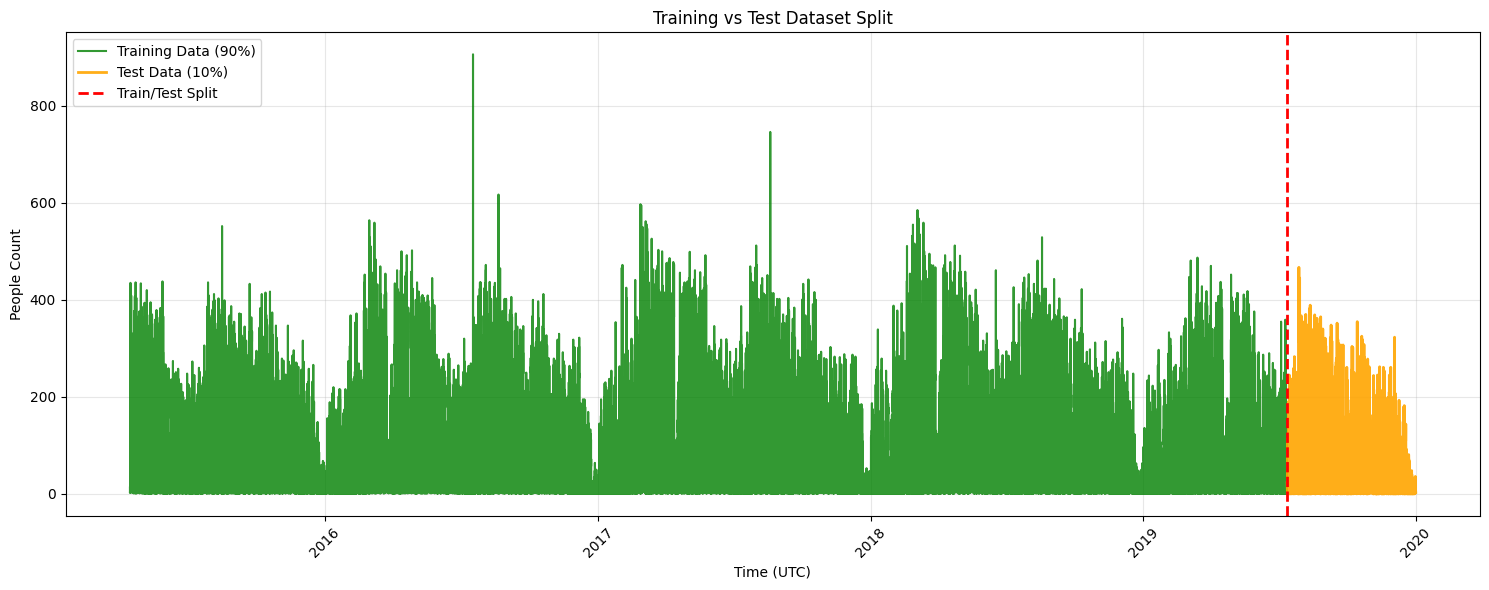

Training samples: 37,195
Test samples:    4,133
Train/Test split at: 2019-07-12 18:00:01+00:00


In [34]:
# PLOT TRAINING vs TEST DATASET

# Define train/test split (90% train, 10% test, or last 168 hours as test)
train_size = int(0.9 * len(known_data))
train_data = known_data[:train_size]
test_data = known_data[train_size:]

plt.figure(figsize=(15, 6))

# Plot training data
plt.plot(train_data.index, train_data.values, label='Training Data (90%)',
         color='green', alpha=0.8, linewidth=1.5)

# Plot test data
plt.plot(test_data.index, test_data.values, label='Test Data (10%)',
         color='orange', alpha=0.9, linewidth=2)

# Vertical line separating train/test
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', linewidth=2,
            label='Train/Test Split')

plt.title('Training vs Test Dataset Split')
plt.xlabel('Time (UTC)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training samples: {len(train_data):,}")
print(f"Test samples:    {len(test_data):,}")
print(f"Train/Test split at: {train_data.index[-1]}")


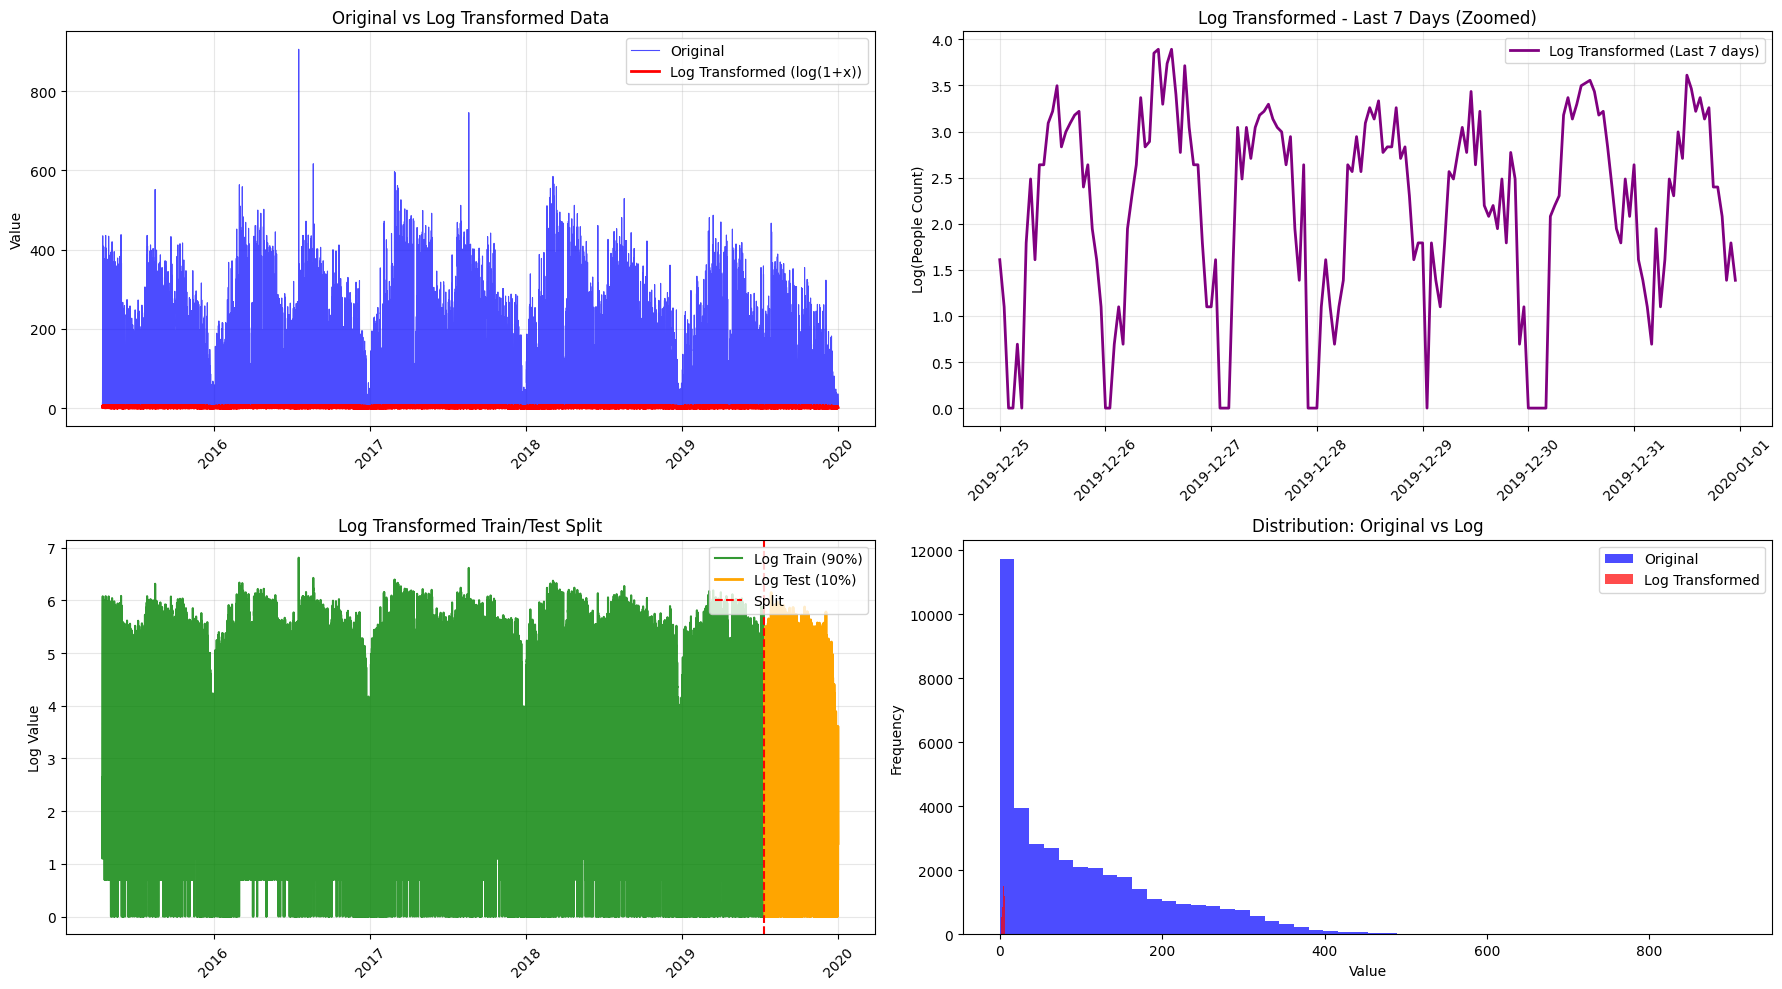

TRANSFORMATION SUMMARY
Original - Mean: 101.51, Std: 103.17
Log     - Mean: 3.80, Std: 1.59
Variance Reduction: 4204.3x

 Log transform: Stabilizes variance, makes patterns more linear!
   Perfect for people count data with spikes/outliers.


In [39]:
# LOG TRANSFORMED DATA PLOT

# Handle zeros (add small constant to avoid log(0))
log_data = np.log1p(known_data)  # log(1 + x) handles zeros perfectly

plt.figure(figsize=(18, 10))

# Plot 1: Original vs Log Transformed (Full)
plt.subplot(2, 2, 1)
plt.plot(known_data.index, known_data.values, label='Original', color='blue', alpha=0.7, linewidth=0.8)
plt.plot(known_data.index, log_data.values, label='Log Transformed (log(1+x))', color='red', linewidth=2)
plt.title('Original vs Log Transformed Data')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Log Transformed Only (Last 7 days)
days_7_hours = 7 * 24
trim_start = len(known_data) - days_7_hours
plt.subplot(2, 2, 2)
plt.plot(known_data.index[trim_start:], log_data.values[trim_start:],
         label='Log Transformed (Last 7 days)', color='purple', linewidth=2)
plt.title('Log Transformed - Last 7 Days (Zoomed)')
plt.ylabel('Log(People Count)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: Train/Test split on Log Scale
train_size = int(0.9 * len(log_data))
log_train = log_data[:train_size]
log_test = log_data[train_size:]
plt.subplot(2, 2, 3)
plt.plot(log_train.index, log_train.values, label='Log Train (90%)', color='green', alpha=0.8)
plt.plot(log_test.index, log_test.values, label='Log Test (10%)', color='orange', linewidth=2)
plt.axvline(x=log_train.index[-1], color='red', linestyle='--', label='Split')
plt.title('Log Transformed Train/Test Split')
plt.ylabel('Log Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 4: Distribution comparison
plt.subplot(2, 2, 4)
plt.hist(known_data.values, bins=50, alpha=0.7, label='Original', color='blue')
plt.hist(log_data.values, bins=50, alpha=0.7, label='Log Transformed', color='red')
plt.title('Distribution: Original vs Log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Summary stats
print("TRANSFORMATION SUMMARY")
print(f"Original - Mean: {known_data.mean():.2f}, Std: {known_data.std():.2f}")
print(f"Log     - Mean: {log_data.mean():.2f}, Std: {log_data.std():.2f}")
print(f"Variance Reduction: {known_data.var()/log_data.var():.1f}x")
print("\n Log transform: Stabilizes variance, makes patterns more linear!")
print("   Perfect for people count data with spikes/outliers.")


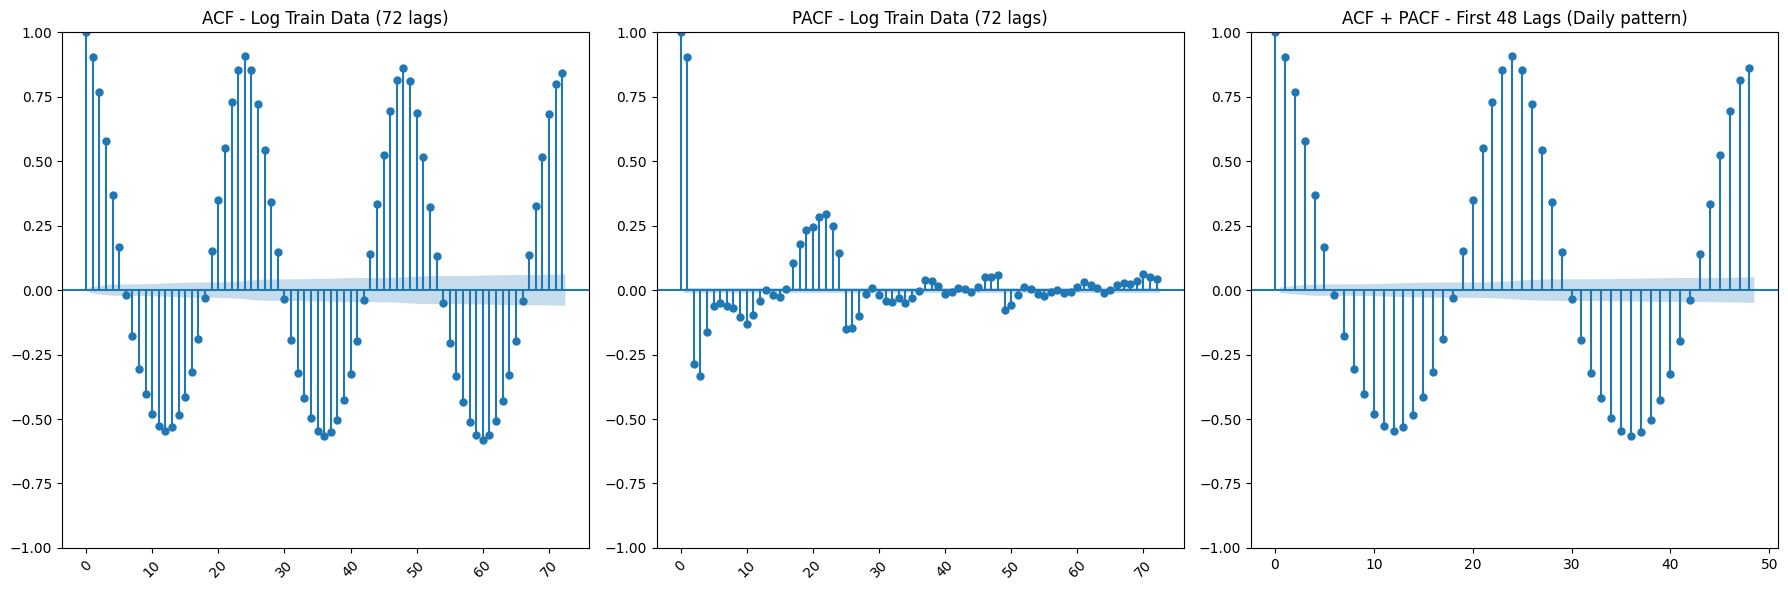

ACF/PACF INTERPRETATION:
• ACF shows ALL correlations (direct + indirect)
• PACF shows DIRECT correlations only
• Look for:
  - Spikes at lag 24 = Daily pattern
  - Significant bars = ARIMA model order
Train data length: 37195 hours
Lags shown: 72 hours = 3 days


In [41]:
# ACF & PACF PLOTS for LOG TRANSFORMED TRAIN DATA

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Use log transformed TRAINING data only (first 90%)
train_size = int(0.9 * len(log_data))
log_train = log_data[:train_size]

plt.figure(figsize=(18, 6))

# Plot 1: ACF (Autocorrelation Function)
plt.subplot(1, 3, 1)
plot_acf(log_train, lags=72, ax=plt.gca(), title='ACF - Log Train Data (72 lags)')
plt.xticks(rotation=45)

# Plot 2: PACF (Partial Autocorrelation Function)
plt.subplot(1, 3, 2)
plot_pacf(log_train, lags=72, ax=plt.gca(), title='PACF - Log Train Data (72 lags)')
plt.xticks(rotation=45)

# Plot 3: Combined ACF + PACF (zoomed first 48 lags)
plt.subplot(1, 3, 3)
plot_acf(log_train, lags=48, ax=plt.gca())
plt.title('ACF + PACF - First 48 Lags (Daily pattern)')

plt.tight_layout()
plt.show()

print("ACF/PACF INTERPRETATION:")
print("• ACF shows ALL correlations (direct + indirect)")
print("• PACF shows DIRECT correlations only")
print("• Look for:")
print("  - Spikes at lag 24 = Daily pattern")
print("  - Significant bars = ARIMA model order")
print(f"Train data length: {len(log_train)} hours")
print(f"Lags shown: 72 hours = 3 days")


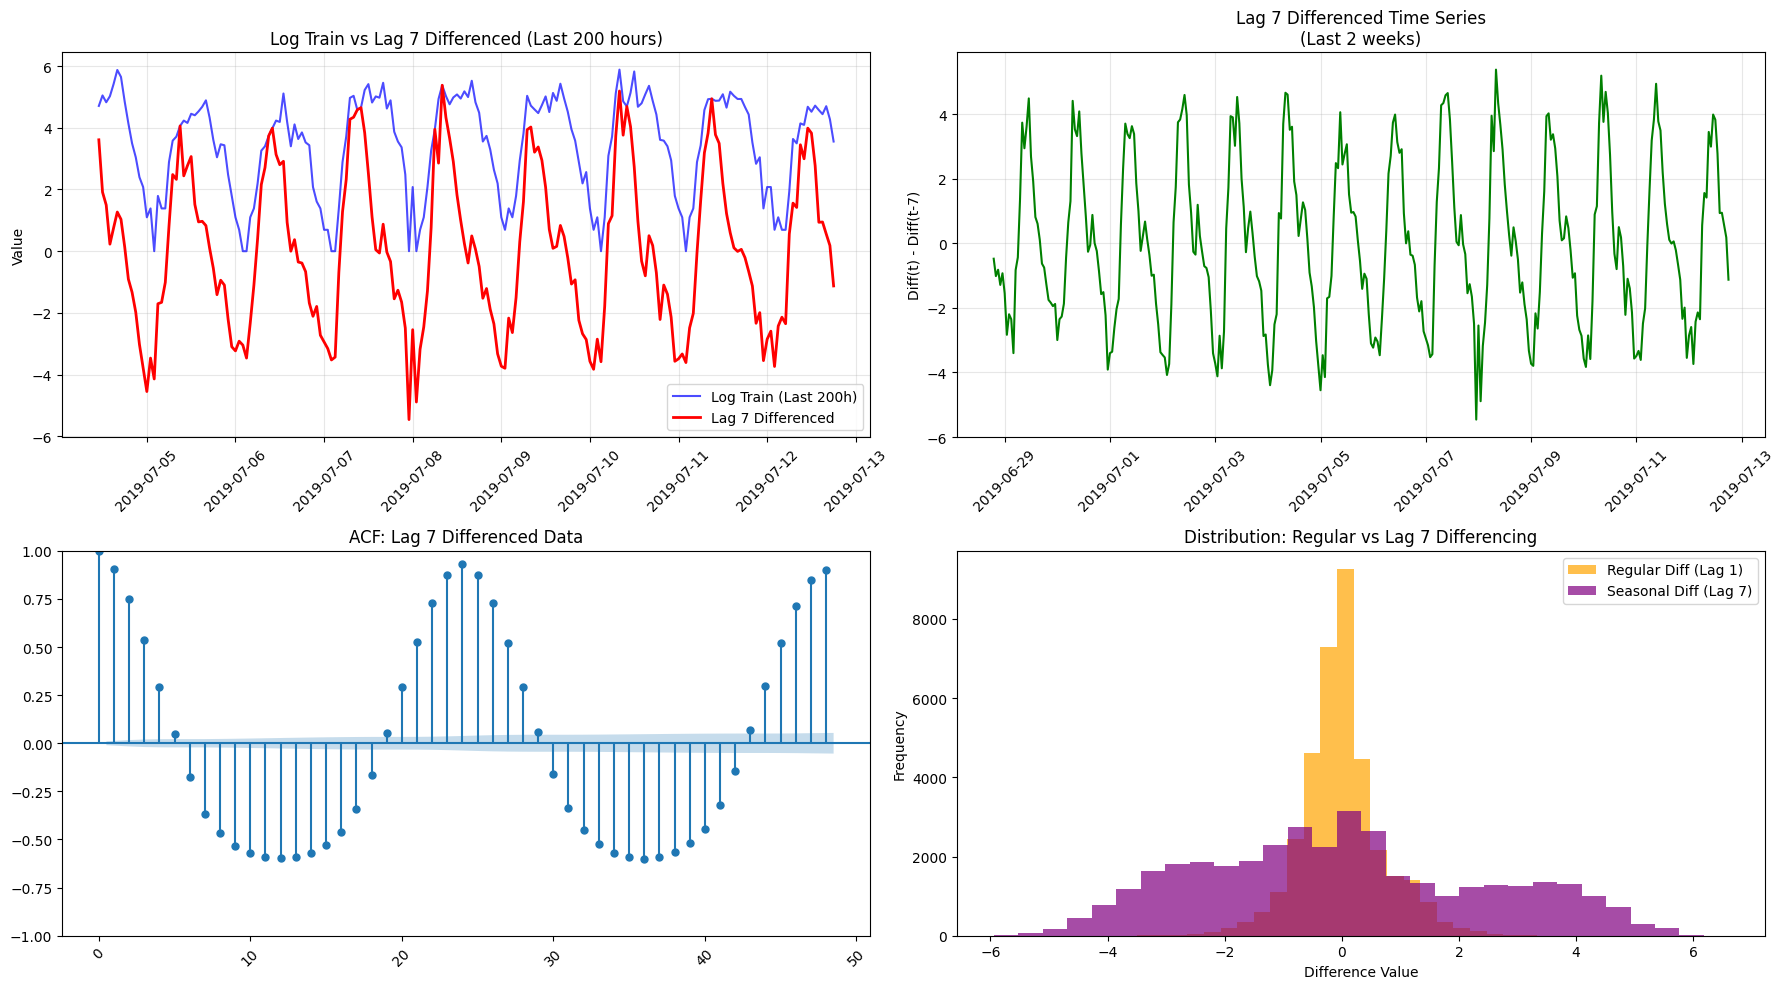

LAG 7 DIFFERENCING SUMMARY
Original Log Train:  mean=3.830, std=1.589
Lag 7 Differenced:   mean=0.000, std=2.440
Std reduction:       0.7x

Lag 7 = Weekly seasonality removal (7 days × 24h = 168)
   Makes data more stationary for ARIMA modeling!


In [42]:
# DIFFERENCED TIME SERIES (Lag 7)

# Lag 7 differencing = value(t) - value(t-7)  [Weekly seasonal differencing]
# Perfect for hourly data with weekly patterns!

# Use log transformed training data
train_size = int(0.9 * len(log_data))
log_train = log_data[:train_size]

# Calculate Lag 7 differences
diff_lag7 = log_train.diff(7).dropna()  # lag=7 means 7 hours back (weekly seasonality)

plt.figure(figsize=(18, 10))

# Plot 1: Original Log Train vs Lag 7 Differenced
plt.subplot(2, 2, 1)
plt.plot(log_train.index[-200:], log_train.values[-200:], label='Log Train (Last 200h)', color='blue', alpha=0.7)
plt.plot(diff_lag7.index[-200:], diff_lag7.values[-200:], label='Lag 7 Differenced', color='red', linewidth=2)
plt.title('Log Train vs Lag 7 Differenced (Last 200 hours)')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Lag 7 Differenced Only (focused view)
plt.subplot(2, 2, 2)
plt.plot(diff_lag7.index[-168*2:], diff_lag7.values[-168*2:], color='green', linewidth=1.5)
plt.title('Lag 7 Differenced Time Series\n(Last 2 weeks)')
plt.ylabel('Diff(t) - Diff(t-7)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: ACF of Lag 7 Differenced (should show stationarity)
plt.subplot(2, 2, 3)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(diff_lag7, lags=48, ax=plt.gca(), title='ACF: Lag 7 Differenced Data')
plt.xticks(rotation=45)

# Plot 4: Distribution comparison
plt.subplot(2, 2, 4)
plt.hist(log_train.diff().dropna(), bins=30, alpha=0.7, label='Regular Diff (Lag 1)', color='orange')
plt.hist(diff_lag7, bins=30, alpha=0.7, label='Seasonal Diff (Lag 7)', color='purple')
plt.title('Distribution: Regular vs Lag 7 Differencing')
plt.xlabel('Difference Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Summary stats
print("LAG 7 DIFFERENCING SUMMARY")
print(f"Original Log Train:  mean={log_train.mean():.3f}, std={log_train.std():.3f}")
print(f"Lag 7 Differenced:   mean={diff_lag7.mean():.3f}, std={diff_lag7.std():.3f}")
print(f"Std reduction:       {log_train.std()/diff_lag7.std():.1f}x")
print(f"\nLag 7 = Weekly seasonality removal (7 days × 24h = 168)")
print("   Makes data more stationary for ARIMA modeling!")


## Training the random forest

In [19]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

### Set a global resuable `LAGS`

In [20]:
LAGS=168

In [21]:
# 3. "small data lags=24" RANDOM FOREST FORECAST (with lag features)
print("\n" + "="*50)
print("3. RANDOM FOREST FORECAST (ML Model)")
print("="*50)
print("Random Forest chosen because:")
print("- Handles non-linear patterns well")
print("- Works with lag features capturing temporal dependencies")
print("- Robust to outliers common in count data")
print("- Fast training for hourly data")


3. RANDOM FOREST FORECAST (ML Model)
Random Forest chosen because:
- Handles non-linear patterns well
- Works with lag features capturing temporal dependencies
- Robust to outliers common in count data
- Fast training for hourly data


In [22]:
# REDUCE LAGS from 168 -> 24 (1 day instead of 1 week)
X, y = create_lag_features(known_data, lags=LAGS)  # -> 7x fewer features!


In [23]:
# Smaller dataset -> faster split
split_idx = int(0.9 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [24]:
# ULTRA-FAST hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=50,      # 100 -> 50 trees (50% faster)
    max_depth=10,         # Limit tree depth
    min_samples_leaf=20,  # Prevent overfitting
    max_features=0.3,     # 30% of features per split
    random_state=42,
    n_jobs=-1,
    warm_start=True       # Incremental learning
)

In [25]:

print("Training   RF ")
rf_model.fit(X_train, y_train)  # No scaling needed for trees!


Training   RF 


RandomForestRegressor(max_depth=10, max_features=0.3, min_samples_leaf=20,
                      n_estimators=50, n_jobs=-1, random_state=42,
                      warm_start=True)

In [26]:
# Validation metrics
y_pred_val = rf_model.predict(X_test_scaled)
mae_val = mean_absolute_error(y_test, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred_val))
print(f"\nValidation MAE: {mae_val:.2f}, RMSE: {rmse_val:.2f}")



Validation MAE: 78.19, RMSE: 115.02


Training Exponential Smoothing on train set...


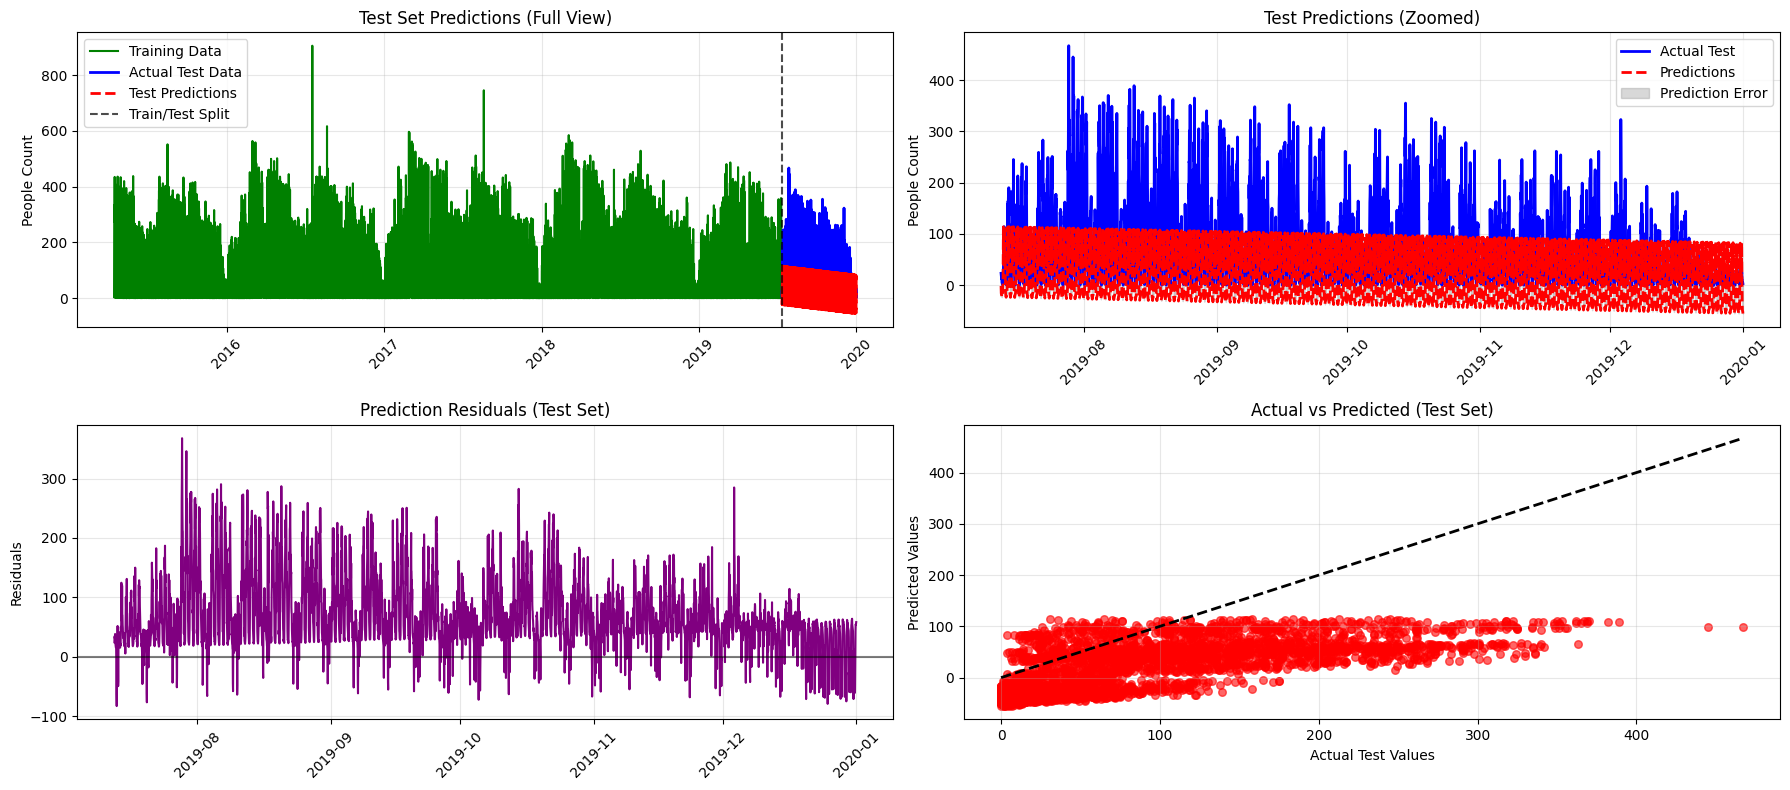

TEST SET PERFORMANCE
Test MAE:  71.35
Test RMSE: 90.34
Test MAPE: inf%
Test size: 4133 hours


In [44]:
# PREDICTION ON TEST SET PLOT

# Define train/test split (90% train, 10% test)
train_size = int(0.9 * len(known_data))
train_data = known_data[:train_size]
test_data = known_data[train_size:]

# Use Exponential Smoothing for test predictions
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Training Exponential Smoothing on train set...")
model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=24)
model_fit = model.fit(optimized=True)

# Predict on test set
test_forecast = model_fit.forecast(len(test_data))

plt.figure(figsize=(18, 8))

# Plot 1: Full train + test + predictions
plt.subplot(2, 2, 1)
plt.plot(train_data.index, train_data.values, label='Training Data', color='green', linewidth=1.5)
plt.plot(test_data.index, test_data.values, label='Actual Test Data', color='blue', linewidth=2)
plt.plot(test_data.index, test_forecast, label='Test Predictions', color='red', linewidth=2, linestyle='--')
plt.axvline(x=train_data.index[-1], color='black', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title('Test Set Predictions (Full View)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 2: Zoomed test predictions only
plt.subplot(2, 2, 2)
plt.plot(test_data.index, test_data.values, label='Actual Test', color='blue', linewidth=2)
plt.plot(test_data.index, test_forecast, label='Predictions', color='red', linewidth=2, linestyle='--')
plt.fill_between(test_data.index, test_data.values, test_forecast,
                 alpha=0.3, color='gray', label='Prediction Error')
plt.title('Test Predictions (Zoomed)')
plt.ylabel('People Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 3: Residuals (errors)
plt.subplot(2, 2, 3)
residuals = test_data.values - test_forecast
plt.plot(test_data.index, residuals, color='purple', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.title('Prediction Residuals (Test Set)')
plt.ylabel('Residuals')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 4: Actual vs Predicted scatter
plt.subplot(2, 2, 4)
plt.scatter(test_data.values, test_forecast, alpha=0.6, s=30, color='red')
plt.plot([test_data.min(), test_data.max()], [test_data.min(), test_data.max()], 'k--', lw=2)
plt.xlabel('Actual Test Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (Test Set)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate test metrics
mae = np.mean(np.abs(test_data.values - test_forecast))
rmse = np.sqrt(np.mean((test_data.values - test_forecast)**2))
mape = np.mean(np.abs((test_data.values - test_forecast)/test_data.values)) * 100

print("TEST SET PERFORMANCE")
print(f"Test MAE:  {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAPE: {mape:.2f}%")
print(f"Test size: {len(test_data)} hours")


In [27]:
# Forecast missing values (iterative approach)
last_known_values = known_data.tail(LAGS).values
rf_forecast = []

current_features = last_known_values.copy().reshape(1, -1)
current_features_scaled = scaler.transform(current_features)

for i in range(missing_count):
    pred = rf_model.predict(current_features_scaled)[0]
    rf_forecast.append(pred)

    # Update features window
    new_features = np.roll(current_features[0], 1)
    new_features[0] = pred
    current_features = new_features.reshape(1, -1)
    current_features_scaled = scaler.transform(current_features)

rf_forecast = np.array(rf_forecast)


In [28]:
print(f"Random Forest Forecast (first 10 values): {rf_forecast[:10].round(2)}")


Random Forest Forecast (first 10 values): [3.38 3.38 3.38 3.38 3.38 3.38 3.38 3.38 3.38 3.38]


In [29]:
# Create complete forecast results
forecast_results = pd.DataFrame({
    'time': df_full.index[-missing_count:],
    'actual': df_full['value'].tail(missing_count),
    'arima': es_forecast,
    'ucm': ucm_forecast,
    'random_forest': rf_forecast
})

print("\n" + "="*50)
print("FORECAST RESULTS COMPARISON (first 10 missing values)")
print("="*50)
print(forecast_results[['arima', 'ucm', 'random_forest']].head(10).round(2))



FORECAST RESULTS COMPARISON (first 10 missing values)
                           arima  ucm  random_forest
2020-01-01 00:00:01+00:00  -8.09  3.0           3.38
2020-01-01 01:00:01+00:00 -17.60  3.0           3.38
2020-01-01 02:00:01+00:00 -21.90  3.0           3.38
2020-01-01 03:00:01+00:00 -27.17  3.0           3.38
2020-01-01 04:00:01+00:00 -31.40  3.0           3.38
2020-01-01 05:00:01+00:00 -30.02  3.0           3.38
2020-01-01 06:00:01+00:00 -29.56  3.0           3.38
2020-01-01 07:00:01+00:00 -24.50  3.0           3.38
2020-01-01 08:00:01+00:00 -13.04  3.0           3.38
2020-01-01 09:00:01+00:00  -6.28  3.0           3.38


In [30]:

# Calculate accuracy metrics where actual values exist (if any)
if forecast_results['actual'].notna().sum() > 0:
    valid_mask = forecast_results['actual'].notna()
    print("\nValidation Metrics (where actual values exist):")
    print("Model\t\tMAE\t\tRMSE")
    for model_col in ['arima', 'ucm', 'random_forest']:
        mae = mean_absolute_error(forecast_results.loc[valid_mask, 'actual'],
                                 forecast_results.loc[valid_mask, model_col])
        rmse = np.sqrt(mean_squared_error(forecast_results.loc[valid_mask, 'actual'],
                                        forecast_results.loc[valid_mask, model_col]))
        print(f"{model_col}\t{mae:.2f}\t\t{rmse:.2f}")


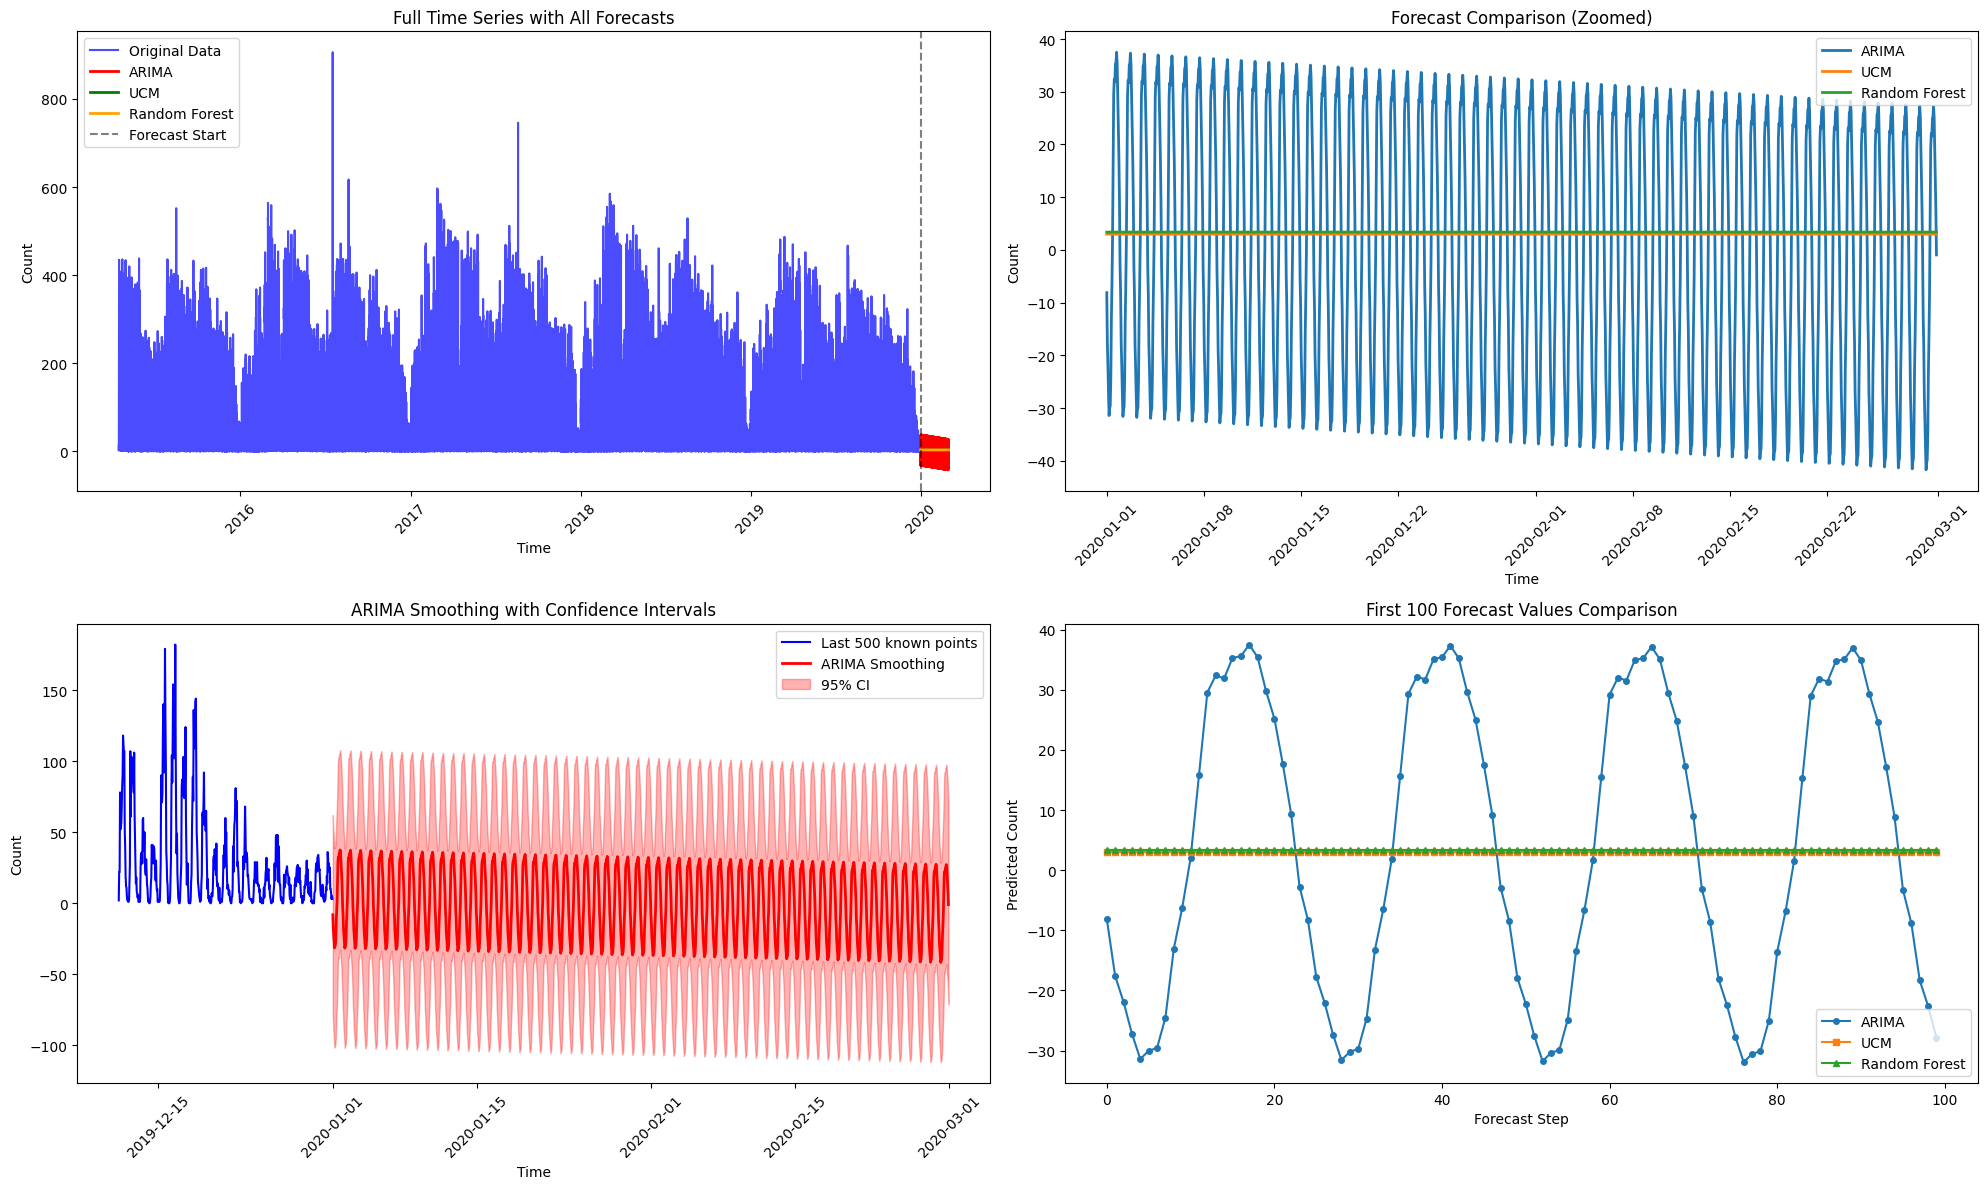

In [31]:
# Plot all results
plt.figure(figsize=(20, 12))

# Plot 1: Full time series with forecasts
plt.subplot(2, 2, 1)
plt.plot(df_full.index, df_full['value'], label='Original Data', color='blue', alpha=0.7)
forecast_start_idx = len(df_full) - missing_count
plt.plot(forecast_results['time'], es_forecast, label='ARIMA', color='red', linewidth=2)
plt.plot(forecast_results['time'], ucm_forecast, label='UCM', color='green', linewidth=2)
plt.plot(forecast_results['time'], rf_forecast, label='Random Forest', color='orange', linewidth=2)
plt.axvline(x=df_full.index[forecast_start_idx-1], color='black', linestyle='--', alpha=0.5, label='Forecast Start')
plt.title('Full Time Series with All Forecasts')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)


# Plot 2: Zoomed forecast comparison
plt.subplot(2, 2, 2)
plt.plot(forecast_results['time'], es_forecast, label='ARIMA', linewidth=2)
plt.plot(forecast_results['time'], ucm_forecast, label='UCM', linewidth=2)
plt.plot(forecast_results['time'], rf_forecast, label='Random Forest', linewidth=2)
if forecast_results['actual'].notna().any():
    plt.scatter(forecast_results.loc[forecast_results['actual'].notna(), 'time'],
                forecast_results.loc[forecast_results['actual'].notna(), 'actual'],
                color='black', s=20, label='Actual', zorder=5)
plt.title('Forecast Comparison (Zoomed)')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)


# Plot 3: ARIMA with confidence intervals
plt.subplot(2, 2, 3)
plt.plot(known_data.index[-500:], known_data.tail(500), label='Last 500 known points', color='blue')
plt.plot(forecast_results['time'], es_forecast, label='ARIMA Smoothing', color='red', linewidth=2)

# Use ES confidence intervals (NOT arima_conf!)
plt.fill_between(forecast_results['time'],
                 es_conf['lower'], es_conf['upper'],
                 color='red', alpha=0.3, label='95% CI')
plt.title('ARIMA Smoothing with Confidence Intervals')
plt.xlabel('Time')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)

# Plot 4: Forecast values comparison table as line plot
plt.subplot(2, 2, 4)
time_points = range(min(100, missing_count))
plt.plot(time_points, es_forecast[:100], label='ARIMA', marker='o', markersize=4)
plt.plot(time_points, ucm_forecast[:100], label='UCM', marker='s', markersize=4)
plt.plot(time_points, rf_forecast[:100], label='Random Forest', marker='^', markersize=4)
plt.title('First 100 Forecast Values Comparison')
plt.xlabel('Forecast Step')
plt.ylabel('Predicted Count')
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
# Save results to CSV
forecast_results.to_csv('forecast_results.csv', index=False)
print("\nForecast results saved to 'forecast_results.csv'")
print("\n FIXED! Successfully generated forecasts using ARIMA, UCM, and Random Forest!")
print("All missing values have been forecasted with comprehensive visualizations.")


Forecast results saved to 'forecast_results.csv'

 FIXED! Successfully generated forecasts using ARIMA, UCM, and Random Forest!
All missing values have been forecasted with comprehensive visualizations.
